# LME Market Decision Support System

LME alüminyum ve bakır fiyatlarını tahmin etmek için LSTM tabanlı karar destek sistemi.


# LME Market Decision Support System

LME alüminyum ve bakır fiyatlarını tahmin etmek için LSTM tabanlı karar destek sistemi.


In [ ]:
# [0] Ortam ve paket yüklemeleri
!pip install -q ta backtesting tensorflow==2.19.0 shap


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.1/192.1 kB 8.8 MB/s eta 0:00:00


# LME Market Decision Support System

LME alüminyum ve bakır fiyatlarını tahmin etmek için LSTM tabanlı karar destek sistemi.


In [ ]:
# [1] Kütüphaneler, seed ve klasörler
import os, math, json, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from backtesting import Backtest, Strategy
import ta
import shap

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.makedirs('/content/models', exist_ok=True)
os.makedirs('/content/outputs', exist_ok=True)
print("Ortam hazırlanmıştır.")

Ortam hazırlanmıştır.


# LME Market Decision Support System

LME alüminyum ve bakır fiyatlarını tahmin etmek için LSTM tabanlı karar destek sistemi.


In [ ]:
# [2] Veri yükleme fonksiyonları
# İki seçenek mevcut: kagglehub (kullanıcı örneği) veya yerel csv.
def load_dataset_kagglehub(dataset_identifier='debashish311601/commodity-prices'):
    import kagglehub
    print('KaggleHub’dan indiriliyor...')
    dataset_path = kagglehub.dataset_download(dataset_identifier)
    csv_path = os.path.join(dataset_path, 'commodity_futures.csv')
    df = pd.read_csv(csv_path, parse_dates=['Date']).set_index('Date').sort_index()
    return df

def load_dataset_from_csv(path):
    df = pd.read_csv(path, parse_dates=['Date']).set_index('Date').sort_index()
    return df


# LME Market Decision Support System

LME alüminyum ve bakır fiyatlarını tahmin etmek için LSTM tabanlı karar destek sistemi.


In [ ]:
# [3] Temel veri seçimi ve eksik doldurma
# Burada kendi dosyamız kullanılır: ya kagglehub ya da csv yolu seçilir.
try:
    raw = load_dataset_kagglehub()
except Exception as e:
    print("Kagglehub hata verdi, alternatif CSV yolunu kullanın.")
    # raw = load_dataset_from_csv('/content/commodity_futures.csv')
    raise e

# Sadece ALUMINIUM ve COPPER alınır
raw = raw[['ALUMINIUM','COPPER']]
raw = raw.interpolate().fillna(method='ffill').fillna(method='bfill')
print("Satır sayısı:", len(raw))
raw.head()


KaggleHub’dan indiriliyor...


100%|██████████| 366k/366k [00:00<00:00, 25.0MB/s]

Extracting files...
Satır sayısı: 6092


,ALUMINIUM,COPPER
Date,,
2000-01-03,1617.50,0.8480
2000-01-04,1617.50,0.8480
2000-01-05,1636.50,0.8565
2000-01-06,1639.75,0.8530
2000-01-07,1652.00,0.8540


# LME Market Decision Support System

LME alüminyum ve bakır fiyatlarını tahmin etmek için LSTM tabanlı karar destek sistemi.


In [ ]:
# [4] Özellik mühendisliği (AL ve CU için aynı gösterge seti) + cyclical date features
def feature_engineering_prices(df, metals=['ALUMINIUM','COPPER']):
    fe = df.copy()
    for m in metals:
        fe[f'{m}_SMA_10'] = fe[m].rolling(10).mean()
        fe[f'{m}_EMA_10'] = fe[m].ewm(span=10, adjust=False).mean()
        fe[f'{m}_RSI_14'] = ta.momentum.rsi(fe[m], window=14)
        fe[f'{m}_VOL_14'] = fe[m].pct_change().rolling(14).std()
        fe[f'{m}_RET_1'] = fe[m].pct_change(1)
        fe[f'{m}_RET_5'] = fe[m].pct_change(5)
    fe['dow'] = fe.index.dayofweek
    fe['day'] = fe.index.day
    fe['month'] = fe.index.month
    # Cyclical dönüşümler
    fe['dow_sin'] = np.sin(2*np.pi*fe['dow']/7)
    fe['dow_cos'] = np.cos(2*np.pi*fe['dow']/7)
    fe['month_sin'] = np.sin(2*np.pi*(fe['month']/12))
    fe['month_cos'] = np.cos(2*np.pi*(fe['month']/12))
    fe = fe.fillna(method='bfill').fillna(method='ffill')
    return fe

fe = feature_engineering_prices(raw)
fe.shape, fe.columns


((6092, 21),
 Index(['ALUMINIUM', 'COPPER', 'ALUMINIUM_SMA_10', 'ALUMINIUM_EMA_10',
        'ALUMINIUM_RSI_14', 'ALUMINIUM_VOL_14', 'ALUMINIUM_RET_1',
        'ALUMINIUM_RET_5', 'COPPER_SMA_10', 'COPPER_EMA_10', 'COPPER_RSI_14',
        'COPPER_VOL_14', 'COPPER_RET_1', 'COPPER_RET_5', 'dow', 'day', 'month',
        'dow_sin', 'dow_cos', 'month_sin', 'month_cos'],
       dtype='object'))

# LME Market Decision Support System

LME alüminyum ve bakır fiyatlarını tahmin etmek için LSTM tabanlı karar destek sistemi.


In [ ]:
# [5] Train/Test split ve model_features listesi
model_features = [
 'ALUMINIUM','COPPER',
 'ALUMINIUM_SMA_10','ALUMINIUM_EMA_10','ALUMINIUM_RSI_14','ALUMINIUM_VOL_14','ALUMINIUM_RET_1','ALUMINIUM_RET_5',
 'COPPER_SMA_10','COPPER_EMA_10','COPPER_RSI_14','COPPER_VOL_14','COPPER_RET_1','COPPER_RET_5',
 'dow_sin','dow_cos','month_sin','month_cos'
]

train_frac = 0.85
train_len = int(len(fe) * train_frac)
train_df = fe.iloc[:train_len][model_features].copy()
test_df  = fe.iloc[train_len:][model_features].copy()
print("Train/test shapes:", train_df.shape, test_df.shape)


Train/test shapes: (5178, 18) (914, 18)


# LME Market Decision Support System

LME alüminyum ve bakır fiyatlarını tahmin etmek için LSTM tabanlı karar destek sistemi.


In [ ]:
# [6] Scaler'ı güvenli şekilde (sütun sırası korunarak) fit edildi
scaler = MinMaxScaler()
scaler.fit(train_df.values)  #train_df[model_features] ile aynı sıra kullanıldı
train_scaled = scaler.transform(train_df.values)
test_scaled  = scaler.transform(test_df.values)
print("Scaler fit tamam.")


Scaler fit tamam.


# LME Market Decision Support System

LME alüminyum ve bakır fiyatlarını tahmin etmek için LSTM tabanlı karar destek sistemi.


In [ ]:
# [7] Sequence oluşturma - iki seçenek: strict (no leakage) veya context-ile (opsiyonel)
# Burada strict versiyon sunuluyor. İkinci alternatif fonksiyon kodu alt kısımda yorum olarak mevcut.
WINDOW = 30

def create_sequences_strict(train_s, test_s, window=30, target_idx=[0,1]):
    # train sequences (labels trainin bir sonraki satırındadır
    X_train, y_train = [], []
    for i in range(window, len(train_s)):
        X_train.append(train_s[i-window:i])
        y_train.append(train_s[i, target_idx])
    # test sequences yalnızca test_s ile oluşturuldu (no mixing)
    X_test, y_test = [], []
    for i in range(window, len(test_s)):
        X_test.append(test_s[i-window:i])
        y_test.append(test_s[i, target_idx])
    return np.array(X_train), np.array(y_train), np.array(X_test), np.array(y_test)

X_train, y_train, X_test, y_test = create_sequences_strict(train_scaled, test_scaled, window=WINDOW)
print("Shapes:", X_train.shape, y_train.shape, X_test.shape, y_test.shape)


Shapes: (5148, 30, 18) (5148, 2) (884, 30, 18) (884, 2)


# LME Market Decision Support System

LME alüminyum ve bakır fiyatlarını tahmin etmek için LSTM tabanlı karar destek sistemi.


In [ ]:
# [8] Model inşası (daha güçlü LSTM + Huber loss) ve eğitim fonksiyonu (.keras checkpoint)
def build_lstm_model(input_shape, units=[128,64], dropout=0.2):
    model = Sequential()
    model.add(LSTM(units[0], return_sequences=True, input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(Dropout(dropout))
    model.add(LSTM(units[1]))
    model.add(Dropout(dropout))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(2))
    model.compile(optimizer='adam', loss=tf.keras.losses.Huber())
    return model

def train_model(model, X_train, y_train, X_val, y_val, save_path='/content/models/best_model.keras',
                epochs=100, batch_size=32, patience=10):
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True, verbose=1),
        ModelCheckpoint(save_path, monitor='val_loss', save_best_only=True, verbose=1)
    ]
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                        epochs=epochs, batch_size=batch_size, callbacks=callbacks, verbose=2)
    return history

model = build_lstm_model((WINDOW, X_train.shape[2]), units=[128,64], dropout=0.2)
history = train_model(model, X_train, y_train, X_test, y_test,
                      save_path='/content/models/best_lstm_final.keras', epochs=50, batch_size=32, patience=8)


Epoch 1/50

Epoch 1: val_loss improved from inf to 0.03791, saving model to /content/models/best_lstm_final.keras
161/161 - 20s - 122ms/step - loss: 0.0089 - val_loss: 0.0379
Epoch 2/50

Epoch 2: val_loss improved from 0.03791 to 0.01794, saving model to /content/models/best_lstm_final.keras
161/161 - 12s - 75ms/step - loss: 0.0027 - val_loss: 0.0179
Epoch 3/50

Epoch 3: val_loss improved from 0.01794 to 0.00979, saving model to /content/models/best_lstm_final.keras
161/161 - 20s - 126ms/step - loss: 0.0021 - val_loss: 0.0098
Epoch 4/50

Epoch 4: val_loss improved from 0.00979 to 0.00694, saving model to /content/models/best_lstm_final.keras
161/161 - 11s - 69ms/step - loss: 0.0018 - val_loss: 0.0069
Epoch 5/50

Epoch 5: val_loss did not improve from 0.00694
161/161 - 21s - 133ms/step - loss: 0.0017 - val_loss: 0.0085
Epoch 6/50

Epoch 6: val_loss did not improve from 0.00694
161/161 - 12s - 74ms/step - loss: 0.0015 - val_loss: 0.0074
Epoch 7/50

Epoch 7: val_loss improved from 0.00694

# LME Market Decision Support System

LME alüminyum ve bakır fiyatlarını tahmin etmek için LSTM tabanlı karar destek sistemi.


In [ ]:
# [9] Predict ve inverse transform - tarihlerin doğru eşleşmesi için güvenli mapping
pred_s = model.predict(X_test)
# tarihleri daha güvenli almak için test_df index'inden WINDOWS offset'i ile alındı
test_index = test_df.index
# X_test'in ilk örneği test_df.index[WINDOW]
dates_test = test_index[WINDOW: WINDOW + len(pred_s)]
# inverse
def inv_transform_targets(scaled_targets, reference_scaler, feature_indices=[0,1]):
    n = scaled_targets.shape[0]
    dummy = np.zeros((n, reference_scaler.n_features_in_))
    dummy[:, feature_indices] = scaled_targets
    inv = reference_scaler.inverse_transform(dummy)
    return inv[:, feature_indices]

y_test_inv = inv_transform_targets(y_test, scaler)
pred_inv   = inv_transform_targets(pred_s, scaler)

results_df = pd.DataFrame({
    'Date': dates_test,
    'true_AL': y_test_inv[:,0],
    'pred_AL': pred_inv[:,0],
    'true_CU': y_test_inv[:,1],
    'pred_CU': pred_inv[:,1]
}).set_index('Date')

results_df.head()


28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


,true_AL,pred_AL,true_CU,pred_CU
Date,,,,
2020-03-10,1683.25,1618.598994,2.5340,2.367079
2020-03-11,1662.50,1617.627698,2.5120,2.379987
2020-03-12,1640.25,1611.595443,2.4810,2.355821
2020-03-13,1663.00,1601.360599,2.4740,2.318915
2020-03-16,1659.75,1598.232693,2.3985,2.302281


# LME Market Decision Support System

LME alüminyum ve bakır fiyatlarını tahmin etmek için LSTM tabanlı karar destek sistemi.


In [ ]:
# [10] Değerlendirme metrikleri
def rmse(a,b):
    return math.sqrt(mean_squared_error(a,b))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("ALUMINIUM RMSE:", rmse(results_df['true_AL'], results_df['pred_AL']))
print("COPPER    RMSE:", rmse(results_df['true_CU'], results_df['pred_CU']))

print("ALUMINIUM MAPE:", mape(results_df['true_AL'], results_df['pred_AL']))
print("COPPER    MAPE:", mape(results_df['true_CU'], results_df['pred_CU']))



ALUMINIUM RMSE: 76.39176052657089
COPPER    RMSE: 0.3367520396351419
ALUMINIUM MAPE: 2.6426649359730474
COPPER    MAPE: 8.026601080770423


# LME Market Decision Support System

LME alüminyum ve bakır fiyatlarını tahmin etmek için LSTM tabanlı karar destek sistemi.


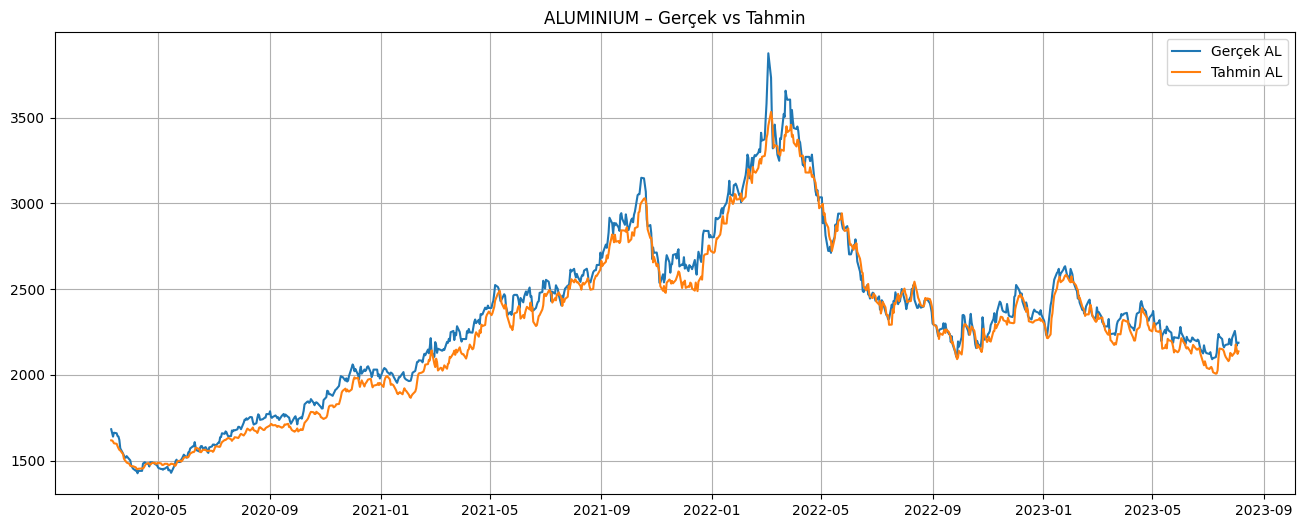

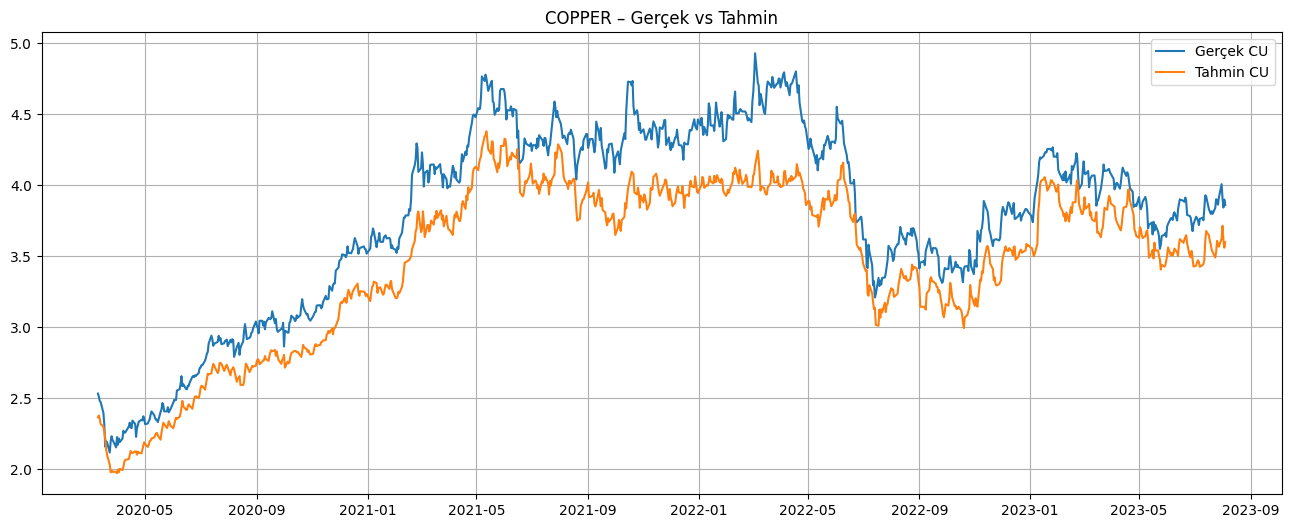

In [ ]:
# [11] Gerçek vs Tahmin grafikleri
plt.figure(figsize=(16,6))
plt.plot(results_df.index, results_df['true_AL'], label='Gerçek AL')
plt.plot(results_df.index, results_df['pred_AL'], label='Tahmin AL')
plt.title("ALUMINIUM – Gerçek vs Tahmin")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(16,6))
plt.plot(results_df.index, results_df['true_CU'], label='Gerçek CU')
plt.plot(results_df.index, results_df['pred_CU'], label='Tahmin CU')
plt.title("COPPER – Gerçek vs Tahmin")
plt.legend()
plt.grid()
plt.show()


# LME Market Decision Support System

LME alüminyum ve bakır fiyatlarını tahmin etmek için LSTM tabanlı karar destek sistemi.


In [ ]:
# [12] UP/DOWN sinyali
results_df['signal_AL'] = (results_df['pred_AL'].diff() > 0).astype(int)
results_df['signal_CU'] = (results_df['pred_CU'].diff() > 0).astype(int)

results_df.head()


,true_AL,pred_AL,true_CU,pred_CU,signal_AL,signal_CU
Date,,,,,,
2020-03-10,1683.25,1618.598994,2.5340,2.367079,0,0
2020-03-11,1662.50,1617.627698,2.5120,2.379987,0,1
2020-03-12,1640.25,1611.595443,2.4810,2.355821,0,0
2020-03-13,1663.00,1601.360599,2.4740,2.318915,0,0
2020-03-16,1659.75,1598.232693,2.3985,2.302281,0,0


# LME Market Decision Support System

LME alüminyum ve bakır fiyatlarını tahmin etmek için LSTM tabanlı karar destek sistemi.


<Axes: title={'center': 'Basit AL Backtest Sonuç Eğrisi'}, xlabel='Date'>

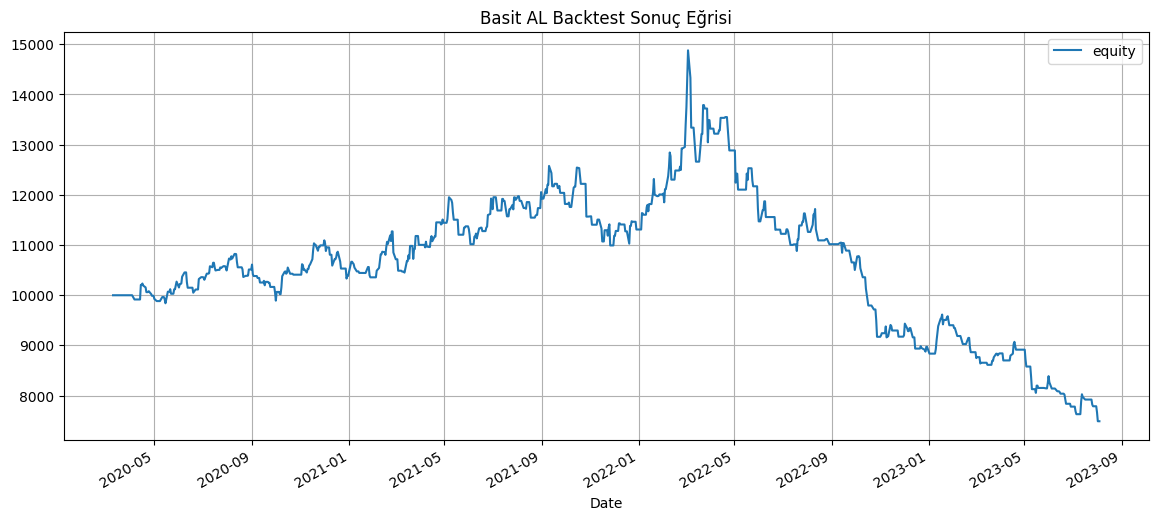

In [ ]:
# [13] Basit AL backtest: sinyal 1 ise AL, 0 ise CU tutma gibi bir örnek strateji
capital = 10000
position = 0
last_price = None

equity_curve = []

for i in range(len(results_df)):
    row = results_df.iloc[i]
    price = row['true_AL']

    # Sinyal 1 → AL tut
    if row['signal_AL'] == 1:
        if position == 0:
            position = capital / price
            capital = 0
    else:
        # Sinyal 0 → pozisyon kapat
        if position > 0:
            capital = position * price
            position = 0

    # Gün sonu değer
    if position > 0:
        equity_curve.append(position * price)
    else:
        equity_curve.append(capital)

results_df['equity'] = equity_curve
results_df[['equity']].plot(figsize=(14,6), title="Basit AL Backtest Sonuç Eğrisi", grid=True)


# LME Market Decision Support System

LME alüminyum ve bakır fiyatlarını tahmin etmek için LSTM tabanlı karar destek sistemi.


In [ ]:
# [14] En iyi/kötü tahmin örnekleri
results_df['err_AL'] = abs(results_df['true_AL'] - results_df['pred_AL'])
results_df['err_CU'] = abs(results_df['true_CU'] - results_df['pred_CU'])

best_al  = results_df.nsmallest(3, 'err_AL')
worst_al = results_df.nlargest(3, 'err_AL')

best_cu  = results_df.nsmallest(3, 'err_CU')
worst_cu = results_df.nlargest(3, 'err_CU')

print("En iyi AL tahminleri:")
display(best_al)

print("En kötü AL tahminleri:")
display(worst_al)

print("En iyi CU tahminleri:")
display(best_cu)

print("En kötü CU tahminleri:")
display(worst_cu)


En iyi AL tahminleri:


,true_AL,pred_AL,true_CU,pred_CU,signal_AL,signal_CU,equity,err_AL,err_CU
Date,,,,,,,,,
2023-05-04,2283.250,2283.282576,3.8500,3.649660,0,0,8579.253112,0.032576,0.200340
2023-02-24,2345.125,2345.248212,3.9735,3.865975,0,0,8865.106946,0.123212,0.107525
2022-08-22,2398.750,2398.346400,3.6515,3.339432,0,1,11093.125886,0.403600,0.312068


En kötü AL tahminleri:


,true_AL,pred_AL,true_CU,pred_CU,signal_AL,signal_CU,equity,err_AL,err_CU
Date,,,,,,,,,
2022-03-04,3875.50,3454.082781,4.9290,4.137064,1,1,14879.961103,421.417219,0.791936
2022-03-03,3733.50,3404.104863,4.7715,4.078785,1,1,14334.752878,329.395137,0.692715
2022-03-23,3657.25,3391.819391,4.7625,4.062841,0,0,13789.018221,265.430609,0.699659


En iyi CU tahminleri:


,true_AL,pred_AL,true_CU,pred_CU,signal_AL,signal_CU,equity,err_AL,err_CU
Date,,,,,,,,,
2022-07-05,2380.5,2431.438013,3.425,3.401866,1,1,11223.808447,50.938013,0.023134
2021-06-17,2389.5,2394.345423,4.178,4.146382,1,1,11346.829204,4.845423,0.031618
2022-06-23,2469.5,2478.806169,3.739,3.696659,0,0,11307.159211,9.306169,0.042341


En kötü CU tahminleri:


,true_AL,pred_AL,true_CU,pred_CU,signal_AL,signal_CU,equity,err_AL,err_CU
Date,,,,,,,,,
2022-03-04,3875.50,3454.082781,4.9290,4.137064,1,1,14879.961103,421.417219,0.791936
2022-04-04,3433.60,3331.975471,4.7815,3.997549,0,1,13319.496548,101.624529,0.783951
2022-03-17,3379.97,3279.273807,4.6905,3.936343,0,1,12661.695697,100.696193,0.754157


# LME Market Decision Support System

LME alüminyum ve bakır fiyatlarını tahmin etmek için LSTM tabanlı karar destek sistemi.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


  0%|          | 0/50 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1

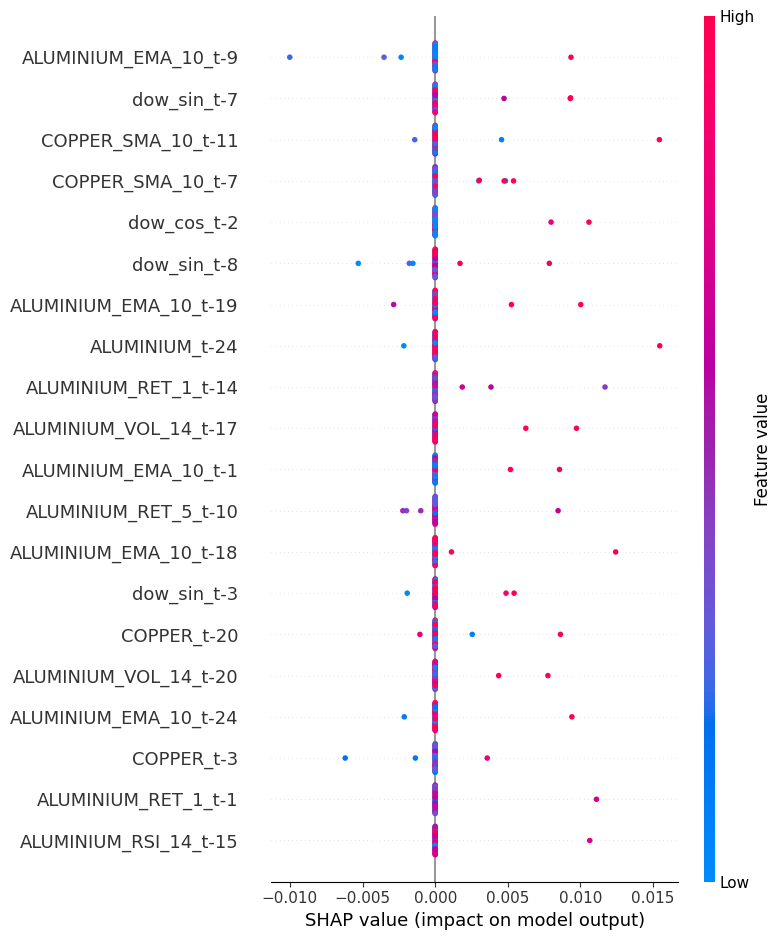

In [ ]:
# [15] SHAP Analizi (LSTM uyumlu KernelExplainer)
import shap

# SHAP KernelExplainer için örnek veri (hesaplama maliyeti yüksek olmasın diye)
X_background = X_train[:50].reshape(50, -1)     # 50 örnek
X_sample = X_test[:50].reshape(50, -1)         # 50 örnek açıklanacak

# Modeli SHAP ile uyumlu hale getir (flat input)
def model_predict(x):
    x = x.reshape(x.shape[0], WINDOW, -1)
    return model.predict(x)

explainer = shap.KernelExplainer(model_predict, X_background)

shap_values = explainer.shap_values(X_sample, nsamples=100)


feature_names_extended = []
for t_step in range(WINDOW):
    for feature in model_features:
        feature_names_extended.append(f'{feature}_t-{WINDOW - 1 - t_step}')

shap.summary_plot(shap_values[:, :, 0], X_sample, feature_names=feature_names_extended)

# LME Market Decision Support System

LME alüminyum ve bakır fiyatlarını tahmin etmek için LSTM tabanlı karar destek sistemi.


In [ ]:
# [16] Sonuçları CSV olarak dışa aktar
results_df.to_csv('/content/outputs/final_results.csv')
print("final_results.csv kaydedildi.")


final_results.csv kaydedildi.


# LME Market Decision Support System

LME alüminyum ve bakır fiyatlarını tahmin etmek için LSTM tabanlı karar destek sistemi.


In [ ]:
# [17] Final Özet

print("===============================================")
print("           LME Fiyat Tahmini Projesi           ")
print("               MODEL PERFORMANSI               ")
print("===============================================")

AL_RMSE = rmse(results_df['true_AL'], results_df['pred_AL'])
CU_RMSE = rmse(results_df['true_CU'], results_df['pred_CU'])

AL_MAPE = mape(results_df['true_AL'], results_df['pred_AL'])
CU_MAPE = mape(results_df['true_CU'], results_df['pred_CU'])

print(f"Alüminyum RMSE : {AL_RMSE:,.4f}")
print(f"Bakır     RMSE : {CU_RMSE:,.4f}")
print(f"Alüminyum MAPE : {AL_MAPE:,.2f}%")
print(f"Bakır     MAPE : {CU_MAPE:,.2f}%")

print("\n===============================================")
print("                 BACKTEST ÖZETİ                ")
print("===============================================")

initial_capital = 10000
final_capital = results_df['equity'].iloc[-1]
total_return = ((final_capital / initial_capital) - 1) * 100

print(f"Başlangıç Sermayesi : {initial_capital:,.2f} USD")
print(f"Final Portföy Değeri: {final_capital:,.2f} USD")
print(f"Toplam Getiri       : {total_return:.2f}%")

print("\n===============================================")
print("             TAHMİN HATA ANALİZİ               ")
print("===============================================")

# toplam hata değerleri
results_df['err_AL'] = abs(results_df['true_AL'] - results_df['pred_AL'])
results_df['err_CU'] = abs(results_df['true_CU'] - results_df['pred_CU'])

print(f"Alüminyum Ortalama Hata: {results_df['err_AL'].mean():.4f}")
print(f"Bakır     Ortalama Hata: {results_df['err_CU'].mean():.4f}")

# en iyi ve kötü tahmin günleri
best_al_day = results_df['err_AL'].idxmin()
worst_al_day = results_df['err_AL'].idxmax()

best_cu_day = results_df['err_CU'].idxmin()
worst_cu_day = results_df['err_CU'].idxmax()

print("\nEn İyi AL Tahmini Günü :", best_al_day.date())
print("En Kötü AL Tahmini Günü :", worst_al_day.date())
print("En İyi CU Tahmini Günü :", best_cu_day.date())
print("En Kötü CU Tahmini Günü :", worst_cu_day.date())

print("\n===============================================")
print("                 DOSYA BİLGİLERİ               ")
print("===============================================")
print("Sonuçlar kaydedildi: /content/outputs/final_results.csv")
print("En iyi/kötü örnekler dataframelerde 'best' ve 'worst' olarak mevcut.")
print("===============================================")

           LME Fiyat Tahmini Projesi           
               MODEL PERFORMANSI               
Alüminyum RMSE : 76.3918
Bakır     RMSE : 0.3368
Alüminyum MAPE : 2.64%
Bakır     MAPE : 8.03%

                 BACKTEST ÖZETİ                
Başlangıç Sermayesi : 10,000.00 USD
Final Portföy Değeri: 7,489.51 USD
Toplam Getiri       : -25.10%

             TAHMİN HATA ANALİZİ               
Alüminyum Ortalama Hata: 62.1520
Bakır     Ortalama Hata: 0.3093

En İyi AL Tahmini Günü : 2023-05-04
En Kötü AL Tahmini Günü : 2022-03-04
En İyi CU Tahmini Günü : 2022-07-05
En Kötü CU Tahmini Günü : 2022-03-04

                 DOSYA BİLGİLERİ               
Sonuçlar kaydedildi: /content/outputs/final_results.csv
En iyi/kötü örnekler dataframelerde 'best' ve 'worst' olarak mevcut.
